In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import glob
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import colors
import matplotlib.ticker as ticker

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm

In [2]:
# Read in data
cd8_t = pd.read_csv('../data/cd8_t_cells_cd8_low_cells_removed_clustering_results_patient_updated.csv', index_col=0)
cd8_t.columns = cd8_t.columns.str.replace('FlowSOM_metacluster_ ', '')
cd8_t['time'] = cd8_t['time'].str.replace('_', '')

In [3]:
cd8_t['patient_tp'] = cd8_t['Patient_ID'] + '_' + cd8_t['time']

In [4]:
cd8_t

,1,2,3,4,5,6,7,8,9,10,...,34,35,36,37,38,39,40,Patient_ID,time,patient_tp
0,112,125,201,16,9,555,5,213,979,103,...,309,615,19,86,171,489,19,P08,C1D8,P08_C1D8
1,21,41,32,0,2,56,0,18,142,12,...,71,256,9,24,24,253,3,P08,C7D1,P08_C7D1
2,12,16,20,1,2,23,0,20,73,10,...,58,142,4,2,20,26,3,P08,C7D22,P08_C7D22
3,25,24,35,3,3,60,0,27,142,11,...,69,183,6,6,12,19,2,P08,SPD,P08_SPD
4,1,3,37,242,2168,970,178,23,520,14,...,201,324,44,162,163,415,13,P24,C1D1,P24_C1D1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,229,225,734,76,26,39,2,359,754,145,...,105,1858,43,76,18,123,37,Control_16,Control,Control_16_Control
114,23,10,19,1017,328,1369,1187,33,7,1,...,228,248,139,84,112,204,17,Control_10,Control,Control_10_Control
115,3,12,13,171,847,1028,873,24,108,89,...,316,4491,114,244,138,567,2,Control_4,Control,Control_4_Control
116,36,16,335,4,12,46,20,47,1778,79,...,41,243,5,10,19,72,2,Control_12,Control,Control_12_Control


In [5]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
cd8_t = cd8_t.loc[cd8_t['patient_tp'] != 'P02_SPD',:]
cd8_t = cd8_t.loc[~cd8_t['patient_tp'].str.contains('P26'),:]
cd8_t['patient_tp'] = cd8_t['patient_tp'].str.replace('P02_SPD_2', 'P02_SPD')

# Delete the following samples as they have only a single measurement
print(cd8_t.shape)
cd8_t = cd8_t.loc[~cd8_t['patient_tp'].str.contains('P27'),:]
print(cd8_t.shape)

(115, 43)
(114, 43)


In [6]:
# Delete the following samples as they have a weird number of CD34+ cells which don't make sense 
print(cd8_t.shape)
cd8_t = cd8_t.loc[(cd8_t['patient_tp'] != 'P04_C1D1') & (cd8_t['patient_tp'] != 'P14_C1D1'), :]
print(cd8_t.shape)

(114, 43)
(112, 43)


In [7]:
# Read in annotation results which are in an excel sheet
annotations = pd.read_excel('../data/2024_06_25_Annotations.xlsx')

# Create a dictionary to map each cell type to a cluster
annotations_dict = {}
for i in annotations['Annotation'].unique():
    a = annotations.loc[annotations['Annotation'] == i,:]
    annotations_dict[i] = a['FlowSOM_Cluster'].astype(str).to_list()
    #print(a)

annotations_dict

{'CD56pos_GzmBpos': ['1',
  '2',
  '3',
  '4',
  '5',
  '8',
  '12',
  '14',
  '15',
  '20',
  '40'],
 'CD56neg_GzmBpos': ['6',
  '7',
  '9',
  '10',
  '11',
  '16',
  '21',
  '22',
  '24',
  '25',
  '28',
  '29',
  '32',
  '34',
  '38'],
 'CD56pos_CD127neg_Trm': ['13', '19', '23', '26'],
 'Activated': ['17', '39'],
 'CD56pos_CD127pos_Trm': ['18'],
 'CD56neg_CD127neg_Trm': ['27', '30'],
 'Memory': ['31', '36', '37'],
 'CD56neg_CD127pos_Trm': ['33'],
 'Naïve/Memory': ['35']}

In [8]:
# Create a function which sums the columns which are part of each cell type
def add_columns(df, sum_dict):
    for new_col, cols_to_sum in sum_dict.items():
        df[new_col] = df[cols_to_sum].sum(axis=1)
    return df

In [9]:
# Add the columns together using the function specified in the cell above
cd8_t = add_columns(cd8_t, annotations_dict)

# Delete the spare columns to make for simpler reading
cd8_t = cd8_t.drop(cd8_t.loc[:,'1':'40'], axis = 1)    
cd8_t.head()

,Patient_ID,time,patient_tp,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory
0,P08,C1D8,P08_C1D8,1114,7964,744,489,141,1032,696,186,615
1,P08,C7D1,P08_C7D1,235,1108,290,253,69,434,281,87,256
2,P08,C7D22,P08_C7D22,142,710,40,26,21,78,157,17,142
3,P08,SPD,P08_SPD,227,1218,37,19,22,67,202,8,183
4,P24,C1D1,P24_C1D1,2539,4558,36,415,13,737,882,105,324


In [10]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows=40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))


In [11]:
# Use the dictionaries to add clinical outcomes to the dataframe
cd8_t['diagnosis'] = cd8_t['Patient_ID'].map(diagnosis_dx)
cd8_t['outcome_6'] = cd8_t['Patient_ID'].map(outcome_C6_dx)
cd8_t['outcome_12'] = cd8_t['Patient_ID'].map(outcome_C12_dx)


In [12]:
# Read in the total number of cells acquired in the T cell panel
total_num = pd.read_csv('../data/t_cell_panel_clustering_results_patient_updated.csv', index_col=0)
total_num.columns = total_num.columns.str.replace('FlowSOM_metacluster_V1', 'Sample')
total_num['Sample'] = total_num['Sample'].str.replace('_T_Cell_Panel', '')
total_num['cell_number'] = total_num.loc[:,'FlowSOM_metacluster_1':'FlowSOM_metacluster_9'].sum(axis=1)

total_num['HSPCs'] = total_num.loc[:,'FlowSOM_metacluster_3']

total_num = total_num.drop(total_num.loc[:, 'FlowSOM_metacluster_1':'FlowSOM_metacluster_9'], axis = 1)

total_num['corrected_cell_num'] = total_num['cell_number'] - total_num['HSPCs']

total_num['Sample'] = total_num['Sample'].str.replace('_D', 'D')

# # # Read in a dataframe which details the number of myeloid cells 
# # # so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/myeloid_panel_patient_metacluster_table_patient_updated.csv', index_col=0)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1':'metacluster_9'].sum(axis = 1) #'metacluster_1''metacluster_2' metacluster_3 metacluster_9
hspc['hspc_lsc'] = hspc[['metacluster_1', 'metacluster_2', 'metacluster_3', 'metacluster_9']].sum(axis=1) # these coliumns are HSPC and aberrant

hspc['ratio_hspc_lsc'] = hspc.loc[:, 'hspc_lsc'].divide(hspc.loc[:, 'total_cells'], axis =0)
hspc['multiplication_factor'] = 1 - hspc.loc[:, 'ratio_hspc_lsc'] 
hspc['PID_Timepoint'] = hspc['FileNames'].str.replace('_Myeloid_Panel', '').str.replace('_C1_', '_C1').str.replace('_C7_', '_C7').str.replace('_C12_', '_C12')
hspc = hspc.loc[:, ['PID_Timepoint', 'multiplication_factor']]

# # # Create a dataframe which details the corrected cell number in each dataframe
total_num = pd.merge(total_num, hspc, left_on = 'Sample', right_on = 'PID_Timepoint')
total_num['corrected_cell_num'] = (total_num['cell_number'] * total_num['multiplication_factor']).astype(int)
total_num = total_num.loc[:, ['Sample', 'cell_number', 'corrected_cell_num']]
total_num


,Sample,cell_number,corrected_cell_num
0,P08_C1D8,93394,79640
1,P08_C7D1,18835,16318
2,P08_C7D22,9829,9382
3,P08_SPD,13073,12357
4,P24_C1D1,35288,23102
...,...,...,...
113,Control_4,220120,217352
114,Control_12,22313,22102
115,Control_11,22313,22115
116,Control_3,96167,95018


In [13]:
hspc

,PID_Timepoint,multiplication_factor
0,P08_C1D8,0.852736
1,P08_C7D1,0.866397
2,P08_C7D22,0.954610
3,P08_SPD,0.945232
4,P24_C1D1,0.654679
...,...,...
113,Control_4,0.987427
114,Control_12,0.990564
115,Control_11,0.991135
116,Control_3,0.988056


In [14]:

cd8_t = pd.merge(cd8_t, total_num, left_on = 'patient_tp', right_on = 'Sample')
cd8_t.head()

,Patient_ID,time,patient_tp,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory,diagnosis,outcome_6,outcome_12,Sample,cell_number,corrected_cell_num
0,P08,C1D8,P08_C1D8,1114,7964,744,489,141,1032,696,186,615,MDS,non-responder_2,non-responder_2,P08_C1D8,93394,79640
1,P08,C7D1,P08_C7D1,235,1108,290,253,69,434,281,87,256,MDS,non-responder_2,non-responder_2,P08_C7D1,18835,16318
2,P08,C7D22,P08_C7D22,142,710,40,26,21,78,157,17,142,MDS,non-responder_2,non-responder_2,P08_C7D22,9829,9382
3,P08,SPD,P08_SPD,227,1218,37,19,22,67,202,8,183,MDS,non-responder_2,non-responder_2,P08_SPD,13073,12357
4,P24,C1D1,P24_C1D1,2539,4558,36,415,13,737,882,105,324,AML,non-responder_2,NaN,P24_C1D1,35288,23102


In [15]:
cd8_t

,Patient_ID,time,patient_tp,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,CD56neg_CD127pos_Trm,Naïve/Memory,diagnosis,outcome_6,outcome_12,Sample,cell_number,corrected_cell_num
0,P08,C1D8,P08_C1D8,1114,7964,744,489,141,1032,696,186,615,MDS,non-responder_2,non-responder_2,P08_C1D8,93394,79640
1,P08,C7D1,P08_C7D1,235,1108,290,253,69,434,281,87,256,MDS,non-responder_2,non-responder_2,P08_C7D1,18835,16318
2,P08,C7D22,P08_C7D22,142,710,40,26,21,78,157,17,142,MDS,non-responder_2,non-responder_2,P08_C7D22,9829,9382
3,P08,SPD,P08_SPD,227,1218,37,19,22,67,202,8,183,MDS,non-responder_2,non-responder_2,P08_SPD,13073,12357
4,P24,C1D1,P24_C1D1,2539,4558,36,415,13,737,882,105,324,AML,non-responder_2,NaN,P24_C1D1,35288,23102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,P13,C7D22,P13_C7D22,9141,20162,1049,400,237,3215,5339,256,2497,MDS,responder_1,responder_1,P13_C7D22,334283,303251
88,P21,C1D1,P21_C1D1,702,944,188,206,65,185,138,44,184,MDS,responder_1,non-responder_2,P21_C1D1,46312,45898
89,P21,C1D8,P21_C1D8,1132,1074,288,139,34,281,173,34,129,MDS,responder_1,non-responder_2,P21_C1D8,34793,31021
90,P21,C7D1,P21_C7D1,3897,3412,2334,775,453,1301,864,199,1068,MDS,responder_1,non-responder_2,P21_C7D1,111678,97877


In [16]:
total_num

,Sample,cell_number,corrected_cell_num
0,P08_C1D8,93394,79640
1,P08_C7D1,18835,16318
2,P08_C7D22,9829,9382
3,P08_SPD,13073,12357
4,P24_C1D1,35288,23102
...,...,...,...
113,Control_4,220120,217352
114,Control_12,22313,22102
115,Control_11,22313,22115
116,Control_3,96167,95018


In [17]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column

time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']

to_del = [x for x, y in zip(cd8_t['patient_tp'], cd8_t['outcome_12']) 
          if 'C7D22' in x and y not in time_to_keep]

to_del
print(cd8_t .shape)
cd8_t  = cd8_t .loc[~cd8_t['patient_tp'].isin(to_del), :]
print(cd8_t.shape)

(92, 18)
(90, 18)


In [18]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y in zip(cd8_t['outcome_6'], cd8_t['outcome_12']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder')
    elif y == 'Healthy':
        best_response.append('Healthy')
    else:
        best_response.append('non-responder')

cd8_t['best_response'] = best_response


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_9839/258005944.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd8_t['best_response'] = best_response


In [19]:
import re

def text_to_int(text_obj):
    # Get the text content from the text object
    text_content = text_obj.get_text()
    
    # Replace Unicode minus sign (U+2212) with ASCII minus sign
    text_content = text_content.replace('\u2212', '-')
    
    # Remove any non-digit characters, but keep the minus sign at the beginning if present
    cleaned_text = re.sub(r'^-?\D*(-?\d+).*$', r'\1', text_content)
    cleaned_text = cleaned_text.replace("''", "")
    try:
        # Try to convert the cleaned string to an integer
        return int(cleaned_text)
    except ValueError:
        print(f"Could not convert '{text_content}' to an integer.")
        return None


In [20]:
# Create a list of patients which have a C7D22 but not a C7D1
patient_tp = []
for i in cd8_t['Patient_ID'].unique():
    a = cd8_t.loc[cd8_t['Patient_ID'] == i, :]
    if ('C7_D1' not in a['time'].to_list()) and ('C7D22' in a['time'].to_list()):
        patient_tp.append(str(i) + '_C7D22')
        
# Filter the dataframe to include only the timepoints of interest
tp_to_keep = ['C1D1', 'C7D1']
cd8_t = cd8_t.loc[(cd8_t['time'].isin(tp_to_keep)) | (cd8_t['patient_tp'].isin(patient_tp)), :]
cd8_t['Cycle_day'] = cd8_t['time']
cd8_t['time_point1'] = ((cd8_t['Cycle_day'] == 'C7D1') | (cd8_t['Cycle_day'] == 'C7D22')).astype(int)
cd8_t['time_point1']

1     1
2     1
4     0
6     1
7     0
9     1
11    0
14    1
17    1
18    0
21    1
22    1
23    0
26    1
27    1
28    0
31    1
32    1
33    0
35    1
36    1
38    1
40    0
43    0
45    1
46    1
47    0
50    1
51    1
52    0
55    1
56    1
57    0
59    0
62    1
63    1
66    1
67    0
69    1
70    1
72    0
74    1
75    1
77    0
79    1
81    0
83    0
86    1
87    1
88    0
90    1
91    1
Name: time_point1, dtype: int64

In [21]:
# Convert columns to percentages
cd8_t.loc[:, 'CD56pos_GzmBpos': 'Naïve/Memory'] = cd8_t.loc[:, 'CD56pos_GzmBpos': 'Naïve/Memory'].divide(cd8_t.loc[:, 'corrected_cell_num'], axis =0) *100
cd8_t

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_9839/3327851007.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.44012747  1.51353656 10.99039044  1.14145209  0.07216309 14.73855431
  1.54709241 18.95604621  8.05477002  3.99697271  8.17928946  4.37320164
  0.3327984  14.32190246 11.34518229  2.45421944  5.75042201  8.15340366
  0.14987746  1.1123144   1.36867072  3.21764414  0.76305461  0.75183932
  0.38465864  0.35063114  1.88606719  4.36271488  3.20340502  0.39301579
  5.33107345  5.42244458  2.06900429  3.66793484  6.55721293  4.56849291
 11.17481037  0.75095155  2.62878588  1.08638895  0.25237579  0.57753026
  0.31079059  5.4471219   1.81408869  1.05365693  2.26672628  4.17495864
  3.01433466  1.52947841  3.98152784  3.10960102]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cd8_t.loc[:, 'CD56pos_GzmBpos': 'Naïve/Memory'] = cd8_t.loc[:, 'CD56pos_GzmBp

,Patient_ID,time,patient_tp,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,...,Naïve/Memory,diagnosis,outcome_6,outcome_12,Sample,cell_number,corrected_cell_num,best_response,Cycle_day,time_point1
1,P08,C7D1,P08_C7D1,1.440127,6.790048,1.777179,1.550435,0.422846,2.659640,1.722025,...,1.568820,MDS,non-responder_2,non-responder_2,P08_C7D1,18835,16318,non-responder,C7D1,1
2,P08,C7D22,P08_C7D22,1.513537,7.567683,0.426348,0.277126,0.223833,0.831379,1.673417,...,1.513537,MDS,non-responder_2,non-responder_2,P08_C7D22,9829,9382,non-responder,C7D22,1
4,P24,C1D1,P24_C1D1,10.990390,19.729894,0.155831,1.796381,0.056272,3.190200,3.817851,...,1.402476,AML,non-responder_2,NaN,P24_C1D1,35288,23102,non-responder,C1D1,0
6,P24,C7D1,P24_C7D1,1.141452,23.914250,0.245163,1.304414,0.082923,5.284714,7.290007,...,2.973688,AML,non-responder_2,NaN,P24_C7D1,176507,138683,non-responder,C7D1,1
7,P19,C1D1,P19_C1D1,0.072163,0.233528,0.016036,0.030068,0.000000,0.060136,0.044100,...,0.020045,CMML,responder_1,NaN,P19_C1D1,104965,99774,responder,C1D1,0
9,P19,C7D1,P19_C7D1,14.738554,31.841625,0.404666,0.343172,0.424502,1.910259,7.658891,...,1.259621,CMML,responder_1,NaN,P19_C7D1,51172,50412,responder,C7D1,1
11,P12,C1D1,P12_C1D1,1.547092,1.139862,2.304163,0.299039,0.037346,0.730709,0.104897,...,0.113410,MDS,responder_1,responder_1,P12_C1D1,377832,364167,responder,C1D1,0
14,P12,C7D22,P12_C7D22,18.956046,18.423439,2.547692,0.085206,0.175344,0.916720,1.260558,...,0.359729,MDS,responder_1,responder_1,P12_C7D22,369380,364997,responder,C7D22,1
17,P04,C7D22,P04_C7D22,8.054770,8.120634,1.079811,0.207865,0.893699,0.876175,1.807942,...,4.525294,AML,responder_1,non-responder_2,P04_C7D22,172595,165492,responder,C7D22,1
18,P03,C1D1,P03_C1D1,3.996973,5.591032,0.186841,0.307459,0.170285,0.706368,1.757249,...,1.474229,MDS,responder_1,responder_1,P03_C1D1,128241,126846,responder,C1D1,0


In [22]:
cd8_t

,Patient_ID,time,patient_tp,CD56pos_GzmBpos,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,Activated,CD56pos_CD127pos_Trm,CD56neg_CD127neg_Trm,Memory,...,Naïve/Memory,diagnosis,outcome_6,outcome_12,Sample,cell_number,corrected_cell_num,best_response,Cycle_day,time_point1
1,P08,C7D1,P08_C7D1,1.440127,6.790048,1.777179,1.550435,0.422846,2.659640,1.722025,...,1.568820,MDS,non-responder_2,non-responder_2,P08_C7D1,18835,16318,non-responder,C7D1,1
2,P08,C7D22,P08_C7D22,1.513537,7.567683,0.426348,0.277126,0.223833,0.831379,1.673417,...,1.513537,MDS,non-responder_2,non-responder_2,P08_C7D22,9829,9382,non-responder,C7D22,1
4,P24,C1D1,P24_C1D1,10.990390,19.729894,0.155831,1.796381,0.056272,3.190200,3.817851,...,1.402476,AML,non-responder_2,NaN,P24_C1D1,35288,23102,non-responder,C1D1,0
6,P24,C7D1,P24_C7D1,1.141452,23.914250,0.245163,1.304414,0.082923,5.284714,7.290007,...,2.973688,AML,non-responder_2,NaN,P24_C7D1,176507,138683,non-responder,C7D1,1
7,P19,C1D1,P19_C1D1,0.072163,0.233528,0.016036,0.030068,0.000000,0.060136,0.044100,...,0.020045,CMML,responder_1,NaN,P19_C1D1,104965,99774,responder,C1D1,0
9,P19,C7D1,P19_C7D1,14.738554,31.841625,0.404666,0.343172,0.424502,1.910259,7.658891,...,1.259621,CMML,responder_1,NaN,P19_C7D1,51172,50412,responder,C7D1,1
11,P12,C1D1,P12_C1D1,1.547092,1.139862,2.304163,0.299039,0.037346,0.730709,0.104897,...,0.113410,MDS,responder_1,responder_1,P12_C1D1,377832,364167,responder,C1D1,0
14,P12,C7D22,P12_C7D22,18.956046,18.423439,2.547692,0.085206,0.175344,0.916720,1.260558,...,0.359729,MDS,responder_1,responder_1,P12_C7D22,369380,364997,responder,C7D22,1
17,P04,C7D22,P04_C7D22,8.054770,8.120634,1.079811,0.207865,0.893699,0.876175,1.807942,...,4.525294,AML,responder_1,non-responder_2,P04_C7D22,172595,165492,responder,C7D22,1
18,P03,C1D1,P03_C1D1,3.996973,5.591032,0.186841,0.307459,0.170285,0.706368,1.757249,...,1.474229,MDS,responder_1,responder_1,P03_C1D1,128241,126846,responder,C1D1,0


In [23]:
cd8_t.columns

Index(['Patient_ID', 'time', 'patient_tp', 'CD56pos_GzmBpos',
       'CD56neg_GzmBpos', 'CD56pos_CD127neg_Trm', 'Activated',
       'CD56pos_CD127pos_Trm', 'CD56neg_CD127neg_Trm', 'Memory',
       'CD56neg_CD127pos_Trm', 'Naïve/Memory', 'diagnosis', 'outcome_6',
       'outcome_12', 'Sample', 'cell_number', 'corrected_cell_num',
       'best_response', 'Cycle_day', 'time_point1'],
      dtype='object')

In [24]:
# Create a function to run the mixed-effects model for a single cell types
def run_mixed_model(df, column):
    model_data = df[['Patient_ID', 'time_point1', column]].copy()
    model_data.columns = ['Patient_ID', 'time_point1', 'value']
    
    # Fit a linear mixed-effects model
    model = smf.mixedlm('value ~ time_point1', model_data, groups=model_data['Patient_ID'])
    result = model.fit()
    
    return result

# Run the analysis for each relevant column
r_results = {}
nr_results = {}
for i in cd8_t['best_response'].unique():
    a = cd8_t.loc[cd8_t['best_response'] == i, :]
    for column in a.columns[3:12]:  # Adjust the range as needed
        print(f"Analyzing {column}:")
        result = run_mixed_model(a, column)
        print(result.summary())
        print('\n')
        if i == 'responder':
            r_results[column] = result
        elif i == 'non-responder':
            nr_results[column] = result

Analyzing CD56pos_GzmBpos:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 15      Method:             REML    
No. Groups:       8       Scale:              6.3076  
Min. group size:  1       Log-Likelihood:     -33.4171
Max. group size:  3       Converged:          Yes     
Mean group size:  1.9                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    2.985    1.034  2.887 0.004  0.959  5.011
time_point1 -1.871    1.366 -1.370 0.171 -4.549  0.806
Group Var    1.203    1.381                           



Analyzing CD56neg_GzmBpos:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 15      Method:             REML    
No. Groups:       8       Scale:              5.1589  
Min. group size:  1       

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [25]:
# Add the cell types and corresponding pvalues to a dictionary for each clinical outcome
r_pval_dict = {}
nr_pval_dict = {}
for i in r_results:
    r_pval_dict[i] = r_results[i].pvalues.iloc[1]
for i in nr_results:
    nr_pval_dict[i] = nr_results[i].pvalues.iloc[1]

In [26]:
# Update the p-values in each dictionary to account for multiple testing
def correct_p_values(dict1, dict2):
    # Combine p-values from both dictionaries
    all_p_values = list(dict1.values()) + list(dict2.values())
    
    # Perform FDR correction
    rejected, corrected_p_values, _, _ = smm.multipletests(all_p_values, method='fdr_bh')
    
    # Split the corrected p-values back into two lists
    split_index = len(dict1)
    corrected_dict1 = corrected_p_values[:split_index]
    corrected_dict2 = corrected_p_values[split_index:]
    
    # Update the original dictionaries with corrected p-values
    for (key, _), corrected_p in zip(dict1.items(), corrected_dict1):
        dict1[key] = corrected_p
    
    for (key, _), corrected_p in zip(dict2.items(), corrected_dict2):
        dict2[key] = corrected_p
    
    return dict1, dict2

# Apply the correction
r_pval_dict1, nr_pval_dict1 = correct_p_values(r_pval_dict, nr_pval_dict)

# Print the results
print("Corrected dict1:", r_pval_dict1)
print("Corrected dict2:", nr_pval_dict1)


Corrected dict1: {'CD56pos_GzmBpos': 0.0012289362604038121, 'CD56neg_GzmBpos': 0.007644878192021081, 'CD56pos_CD127neg_Trm': 0.05654029096222737, 'Activated': 0.6940529181625449, 'CD56pos_CD127pos_Trm': 0.0012289362604038121, 'CD56neg_CD127neg_Trm': 0.2412974940436461, 'Memory': 0.007644878192021081, 'CD56neg_CD127pos_Trm': 0.6940529181625449, 'Naïve/Memory': 0.007644878192021081}
Corrected dict2: {'CD56pos_GzmBpos': 0.3415205932484622, 'CD56neg_GzmBpos': 0.828973029597382, 'CD56pos_CD127neg_Trm': 0.6940529181625449, 'Activated': 0.5323138133331393, 'CD56pos_CD127pos_Trm': 0.48272290666310913, 'CD56neg_CD127neg_Trm': 0.48272290666310913, 'Memory': 0.0694236722647748, 'CD56neg_CD127pos_Trm': 0.828973029597382, 'Naïve/Memory': 0.41914542916219527}


In [27]:
# Create a function to add significance stars and a horizontal line which indicates the comparison being
# made to the barplot

def add_significance_stars(ax, x, y, p_value, is_responder, fontsize=8):
    # Map p-value thresholds to stars
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    
    y_limit = ax.get_ylim()[1]
    bar_width = 0.35
    offset = 5.08  # Distance between line and star center
    
    if is_responder:
        # For responders (top): line first, then stars above it
        line_y = y_limit * 0.80
        star_y = line_y + offset
    else:
        # For non-responders (bottom): line first, then stars below it
        line_y = y_limit * -0.80
        star_y = line_y - (offset * 2.5)
    
    # Add horizontal line
    color = 'black' #if is_responder else '#fe9003'
    ax.hlines(y=line_y, xmin=x - bar_width/2, xmax=x + bar_width/2, 
              colors=color, linewidth=0.8, linestyle='-')
    
    # Add the stars with centered alignment for symmetry
    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_9839/1330668579.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = yticklabels, fontsize = 7)


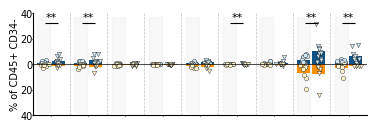

In [28]:
# Make the graph which shows the change in cell type frequency over time

fig, ax = plt.subplots(figsize=(6.3272 * (9/14) * 0.7239, 1.25 * 0.91559))


plt.rcParams.update({'svg.fonttype': 'none', 'pdf.fonttype': 'truetype'})


# Define colors for different times
colors = {'non-responder': '#fe9003', 'responder': '#115284'}

dot_colors  = {'non-responder': '#FFF3CD', 'responder':  '#D0E8F5'}

markers = {'C1D1': 'o', 'C7D1': 'v'}

# Define the categories and their positions on the x-axis
# Define the categories and their positions on the x-axis
categories = ['Naïve/Memory', 'Memory','Activated', 'CD56neg_CD127pos_Trm', 'CD56neg_CD127neg_Trm', 
              'CD56pos_CD127pos_Trm', 'CD56pos_CD127neg_Trm','CD56neg_GzmBpos','CD56pos_GzmBpos']


x_positions = np.arange(len(categories))

# Set the width of each bar
bar_width = 0.35

time_offsets = {'C1D1': -bar_width/2 - 0.025, 'C7D1': bar_width/2 + 0.025}

mean_values = cd8_t.groupby(['best_response', 'time'])[categories].mean()

ax.set_ylim(-37.5, 37.5)

# Plot bars for each outcome and time
for outcome in ['responder', 'non-responder']:
    multiplier = 1 if outcome == 'responder' else -1
    
    for time in ['C1D1', 'C7D1']:
        #offset = -bar_width/2 -0.025 if time == 'C1D1' else bar_width/2 +0.025 
        
        values = mean_values.loc[outcome, time]
       
        # FIRST: Draw hatched background bars for C1_D1 (up to 75)
        if time == 'C1D1':
            hatch_height = 37.5 * multiplier
            ax.bar(x_positions + time_offsets['C1D1'], hatch_height, bar_width,
                   facecolor='lightgrey',  # Light grey background
                   edgecolor='lightgrey',  # Edge for the hatch
                   alpha=0.15)#,
                   #hatch='xxxxxx',
                   #linewidth=0.5,
                   #zorder=1)
            
        ax.bar(x_positions + time_offsets[time], values * multiplier, bar_width, 
               #color = colors[outcome], 
               facecolor = colors[outcome],
               edgecolor = None, 
               alpha=1, 
               label=f'{outcome} - {time}')

        for category in categories:
            category_data = cd8_t[
                (cd8_t['best_response'] == outcome) & (cd8_t['time'] == time)
            ][category]
            
            # Get the disease for each patient in this subset and map to colours
            subset = cd8_t[(cd8_t['best_response'] == outcome) & (cd8_t['time'] == time)]
           # dot_colors = subset['diagnosis'].map(disease_colors).values  # <-- key line
            
            x_jitter = np.random.normal(0, 0.05, size=len(category_data))
            ax.scatter(
                x_positions[categories.index(category)] + time_offsets[time] + x_jitter,
                category_data * multiplier,
                marker=markers[time],
                color=dot_colors[outcome],          # <-- pass the colour array here
                alpha=1, lw=0.25, edgecolor='black',
                s=10
            )
# Add a horizontal line to the graph
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i in range(9):
    ax.axvline(x= i+ bar_width +0.15, color='silver', linestyle='--', linewidth=0.5)


# # Set labels and title 
ax.set_xticks(range(9))
ax.set_ylim(-40, 40)
yticklabels = [40, 20, 0, 20, 40]
ax.set_yticklabels(labels = yticklabels, fontsize = 7)
labels = [i.replace('_', ' ') for i in categories]
labels = [i.replace(' pos', '+') for i in labels]
labels = [i.replace(' neg', '-') for i in labels]
labels = [i.replace(' low progenitor', '+/- precursor') for i in labels]
ax.set_xticklabels(labels = '', rotation = 90, fontsize = 7)
ax.tick_params(axis='both', labelsize=7, pad = -1, length = 1)    
ax.set_xlim(-0.5, 8.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('% of CD45+ CD34-', fontsize = 7, labelpad = 0.1)

# #Add legend

# Add significance stars after setting the y-limits
for outcome in ['responder', 'non-responder']:
    for i, category in enumerate(categories):
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 0, p_value, outcome == 'responder')

fig.set_size_inches(6.3272 * (11/14) * 0.7239, 1.25 * 0.91559)

fig.tight_layout(pad=0.1)
fig.savefig('../results/cell_types_graphs_v2.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)

In [29]:
cd8_t.columns

Index(['Patient_ID', 'time', 'patient_tp', 'CD56pos_GzmBpos',
       'CD56neg_GzmBpos', 'CD56pos_CD127neg_Trm', 'Activated',
       'CD56pos_CD127pos_Trm', 'CD56neg_CD127neg_Trm', 'Memory',
       'CD56neg_CD127pos_Trm', 'Naïve/Memory', 'diagnosis', 'outcome_6',
       'outcome_12', 'Sample', 'cell_number', 'corrected_cell_num',
       'best_response', 'Cycle_day', 'time_point1'],
      dtype='object')

In [30]:
r_pval_dict1

{'CD56pos_GzmBpos': 0.0012289362604038121,
 'CD56neg_GzmBpos': 0.007644878192021081,
 'CD56pos_CD127neg_Trm': 0.05654029096222737,
 'Activated': 0.6940529181625449,
 'CD56pos_CD127pos_Trm': 0.0012289362604038121,
 'CD56neg_CD127neg_Trm': 0.2412974940436461,
 'Memory': 0.007644878192021081,
 'CD56neg_CD127pos_Trm': 0.6940529181625449,
 'Naïve/Memory': 0.007644878192021081}